# Catoctin Basalts ca. 572 Ma paleomagnetic pole

## Geologic context

The Catoctin volcanic province is consists of
subaerial basalts exposed along both limbs of the Blue Ridge
anticlinorium in central Virginia and Maryland (Meert, Van der Voo & Payne, 1994).
It records the second of Neoproterozoic rifting events along the eastern
Laurentian margin associated with the opening of the Iapetus Ocean. The basalts,
feeder dikes (which cut the Grenville Pedlar/Old Rag granite basement), and sills
were variably metamorphosed and folded during the later Taconic and Alleghanian
orogenies, so the rocks carry three magnetization components.

The age constraints for the Catoctin volcanic province come from a 572 ± 5 Ma Concordia isochron upper intercept U-Pb zircon date on a felsic dike within Grenville basement that is interpreted to be a feeder associated with the flows and a 
<sup>207</sup>Pb/<sup>206</sup>Pb zircon date of 564 ± 9 Ma from a rhyolitic flow in the Catoctin. Assign the mean age of these two with the uncertainty bounds including the uncertainty of each. We assign a nominal_age of 568 Ma with bounds that encompass the errors (lomagage=555 Ma, himagage=577).

Previous Nordic compilation noted that: *572±5 in felsic pod from lower Catoctin; 564 Ma in upper Catoctin -lower more applicable to basalts, Aleinikoff +95 Am.J.Sci*

Aleinikoff, J. N., Zartman, R. E., Walter, M., Rankin, D. W., Lyttle, P. T., & Burton, W. C. (1995). U-Pb ages of metarhyolites of the Catoctin and Mount Rogers Formations, central and southern Appalachians; evidence for two pulses of Iapetan rifting. American Journal of Science, 295(4), 428–454. https://doi.org/10.2475/ajs.295.4.428

## Three magnetization components

- **A component, interpretted to be primary ca. 572 Ma** (magnetite): tilt-corrected D=68°/I=+84°.
  Passes the fold test and the reversal test, and a positive baked-contact test
  (Catoctin feeder dikes/sill bake the Pedlar Granite at sites 8 and 28). Pole
  43°S/128°E.
- **B component — Late Cambrian ~505 Ma remagnetization** (hematite, dual
  polarity): tilt-corrected D=92°/I=+17°, passes the fold test; pole 4°S/193°E.
- **C component — Taconic ~450 Ma remagnetization** (magnetite): in-situ
  D=147°/I=+44°, FAILS the fold test; Ordovician pole 19°N/143°E.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/572_Catoctin/sites.txt`. Each component is
stored with in-situ (`dir_tilt_correction == 0`) and, where the paper reports
them, tilt-corrected (`== 100`) rows; the A-component n=1 sites (6, 16) are
flagged `result_quality='b'` and dropped from the pole.

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/572_Catoctin/sites.txt')
print('components (tilt-corrected rows):', sites_tc['dir_comp_name'].value_counts().to_dict())
A_tc = sites_tc[sites_tc['dir_comp_name'] == 'A'].reset_index(drop=True)
A_geo = sites_geo[sites_geo['dir_comp_name'] == 'A'].reset_index(drop=True)
study_lat, study_lon = 38.5, 281.8
print(f'\n{len(A_tc)} A-component sites (n>1) for the pole')
A_tc[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

components (tilt-corrected rows): {'B': 9, 'A': 6}

6 A-component sites (n>1) for the pole


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,2A,256,-74,504.0,6.0,3,-39,151
1,3A,281,80,154.0,6.0,6,-40,87
2,8A,164,89,43.0,8.0,6,-36,113
3,9A,86,76,334.0,5.0,5,-36,145
4,15A,203,-86,97.0,9.0,4,-45,116
5,28A,248,-75,730.0,4.0,4,-44,147


In [3]:
pt.plot_site_map(sites_tc)

## A-component pole

The A-component VGPs lie in the southern hemisphere (Laurentia lay near the south
pole at ca. 570 Ma); the Fisher mean is also reported in the northern-hemisphere
convention of the prior compilation.

A-component pole: 42.4 N / 306.9 E, A95 16.5, K 17.4, N 6
Meert et al. (1994): 43 S / 128 E (= 42.4 N / 306.9 E); prior compilation GPMDB 7474: 42.4/306.9, A95 16.5


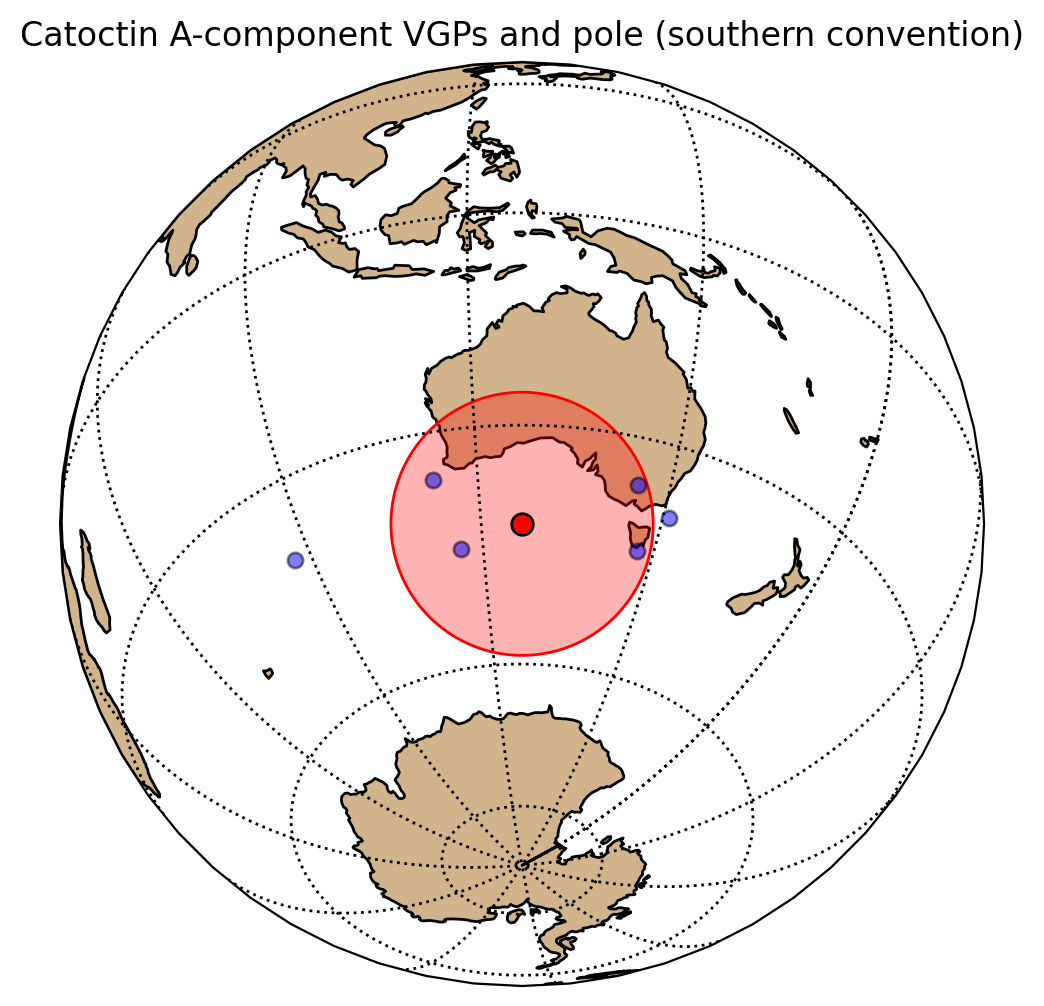

In [4]:
vgp_block, pole_south = pt.compute_mean_pole(A_tc, unify_polarity=False)
pole_mean = {'inc': -pole_south['inc'], 'dec': (pole_south['dec'] + 180) % 360,
             'alpha95': pole_south['alpha95'], 'k': pole_south['k'], 'n': pole_south['n']}
print(f"A-component pole: {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, "
      f"A95 {pole_mean['alpha95']:.1f}, K {pole_mean['k']:.1f}, N {int(pole_mean['n'])}")
print('Meert et al. (1994): 43 S / 128 E (= 42.4 N / 306.9 E); prior compilation GPMDB 7474: 42.4/306.9, A95 16.5')
ax = pt.plot_vgps_and_pole(vgp_block, pole_south, central_longitude=pole_south['dec'],
                           central_latitude=pole_south['inc'], figsize=(6, 6))
plt.title('Catoctin A-component VGPs and pole (southern convention)')
plt.show()

Dec: 66.8  Inc: 83.6
Number of directions in mean (n): 6
Angular radius of 95% confidence (a_95): 8.7
Precision parameter (k) estimate: 60.3


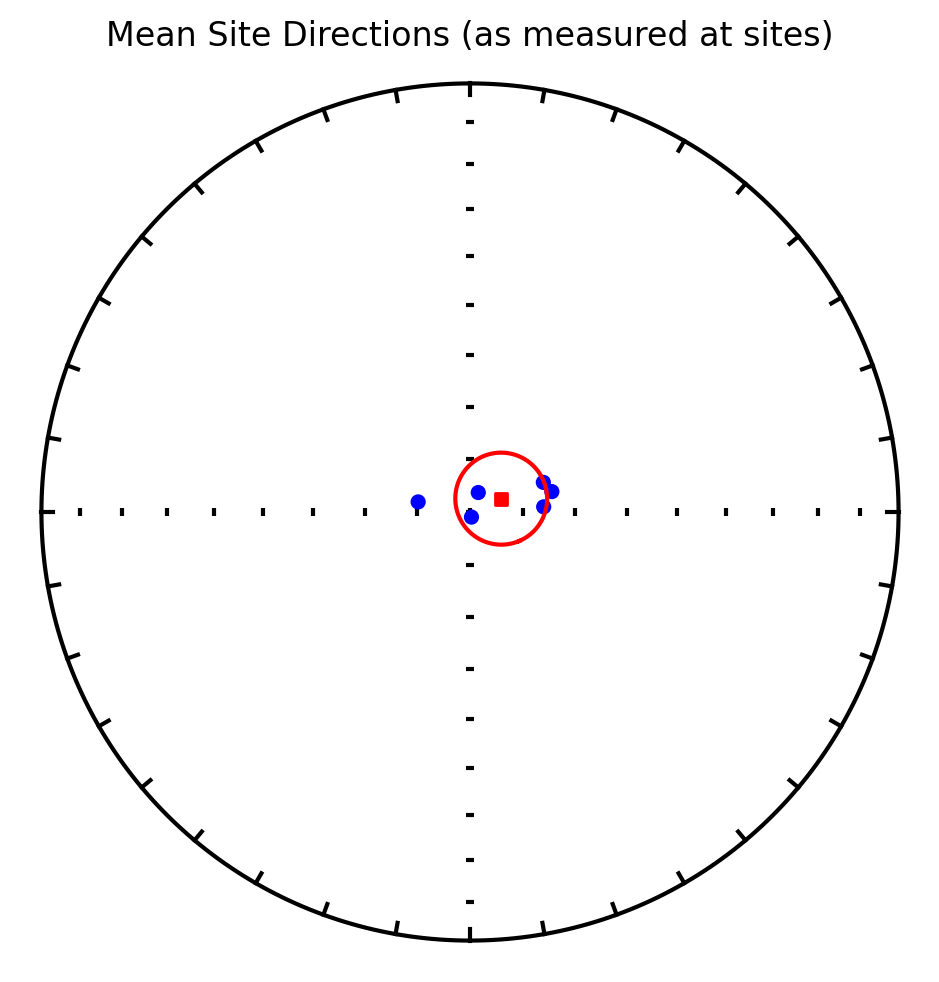

In [5]:
dir_block, dir_mean = pt.compute_mean_direction(A_tc, unify_polarity=True)

ipmag.print_direction_mean(dir_mean)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], 
                   color='red', marker='s')
ipmag.plt.title('Mean Site Directions (as measured at sites)')
ipmag.plt.show()

## Field tests

**Fold test (positive).** The A-component site-mean directions group much more
tightly after tilt correction (the precision parameter k increases), the signature
of a positive fold test; Meert et al. (1994) report a McFadden (1990) fold test
that rejects the in-situ hypothesis, so the magnetization predates the
Taconic-Alleghanian folding.

A component in-situ       : D=342 I=80 k=22.7 a95=14.4
A component tilt-corrected: D=67 I=84 k=60.3 a95=8.7
-> k increases on tilt correction = positive fold test (Meert: k 26 -> 59)


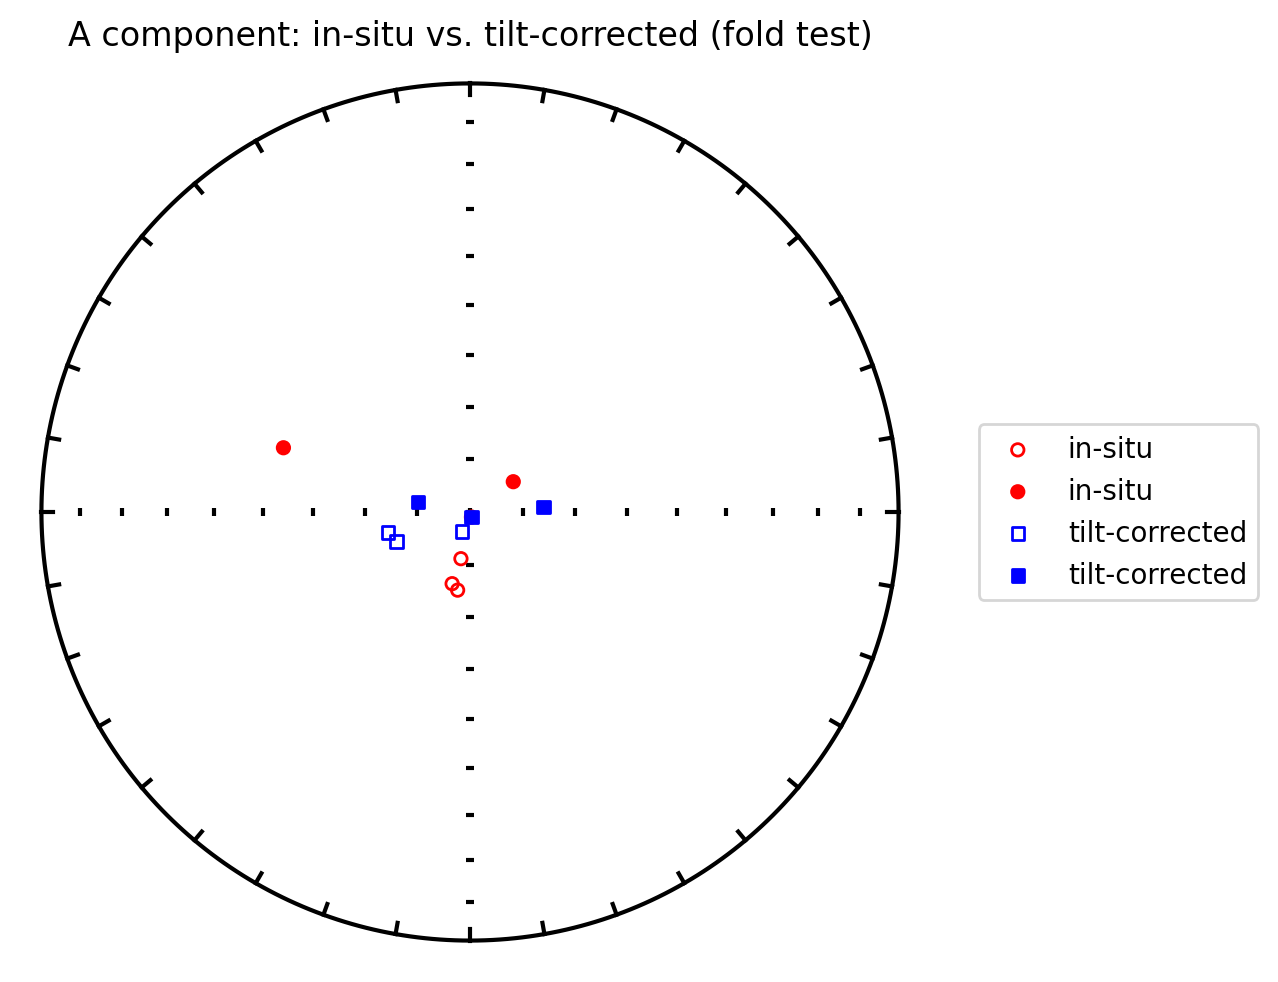

In [6]:
for label, comp in [('in-situ', A_geo), ('tilt-corrected', A_tc)]:
    fm = pmag.fisher_mean(pmag.flip(ipmag.make_di_block(comp['dir_dec'].tolist(),
                                                        comp['dir_inc'].tolist()), combine=True))
    print(f'A component {label:14s}: D={fm["dec"]:.0f} I={fm["inc"]:.0f} k={fm["k"]:.1f} a95={fm["alpha95"]:.1f}')
print('-> k increases on tilt correction = positive fold test (Meert: k 26 -> 59)')

ipmag.plot_net()
ipmag.plot_di(A_geo['dir_dec'].tolist(), A_geo['dir_inc'].tolist(), color='red', marker='o', label='in-situ')
ipmag.plot_di(A_tc['dir_dec'].tolist(), A_tc['dir_inc'].tolist(), color='blue', marker='s', label='tilt-corrected')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('A component: in-situ vs. tilt-corrected (fold test)')
plt.show()

**Reversal test (positive, class C).** The A component carries both normal and
reversed site directions; Meert et al. (1994) report a positive (class C)
McFadden & McElhinny (1990) reversal test on the tilt-corrected directions.

**Baked-contact test (positive).** At sites 8 and 28, a Catoctin feeder dike and a
sill intrude the Pedlar Granite; the baked granite carries the steep dike/sill
direction while unbaked granite away from the contact does not.

In [7]:
ipmag.reversal_test_MM1990(dec=A_tc['dir_dec'].tolist(),
                                  inc=A_tc['dir_inc'].tolist())

Results of Watson V test: 

Watson's V:           2.7
Critical value of V:  9.1
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 9.6
Critical angle for M&M1990:   17.7
The McFadden and McElhinny (1990) classification for
this test is: 'C'


(1, np.float64(9.63709048689434), np.float64(17.68679411647698), 'C')

## Paleosecular variation and VGP-shape diagnostics

With only six A-component site VGPs the pole is modestly determined (large A95);
the diagnostics are shown for completeness.

A_95 of 16.5 passes Deenen et al. (2011) criteria of being between 5.9 and 26.5 for this number of sites


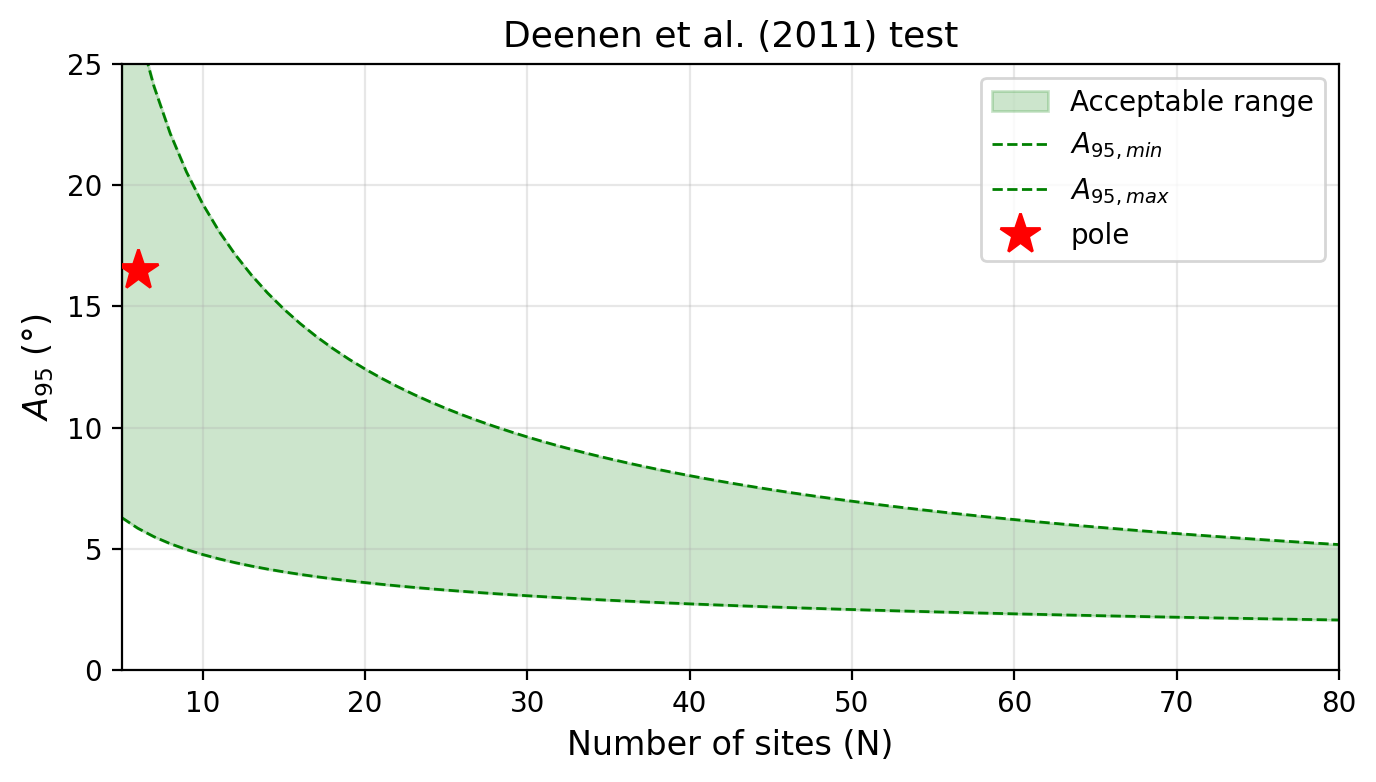

In [8]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
_ = pt.plot_Deenen_test(pole_mean)

In [9]:
fishqq_result = pt.fishqq_vgps(A_tc, unify_polarity=False)
fishqq_result

you need N> 10 for at least one mode


## The secondary B and C components (context)

The same rocks carry two younger remagnetization poles, isolated and dated by
their fold-test behaviour: the B component (Late Cambrian ~505 Ma, passes the fold
test; pole 4°S/193°E) and the C component (Taconic ~450 Ma, fails the fold test;
pole 19°N/143°E). These are plotted for context but are not the Catoctin pole.

In [10]:
for comp, tc_flag, label in [('B', sites_tc, 'B (Late Cambrian ~505 Ma)'),
                             ('C', sites_geo, 'C (Taconic ~450 Ma)')]:
    sub = tc_flag[tc_flag['dir_comp_name'] == comp]
    _, sp = pt.compute_mean_pole(sub, unify_polarity=True)
    print(f'{label:26s}: pole {sp["inc"]:.1f}/{sp["dec"]:.1f} A95 {sp["alpha95"]:.1f} N {int(sp["n"])}')

B (Late Cambrian ~505 Ma) : pole 3.7/13.5 A95 9.9 N 9
C (Taconic ~450 Ma)       : pole 17.8/144.5 A95 8.9 N 15


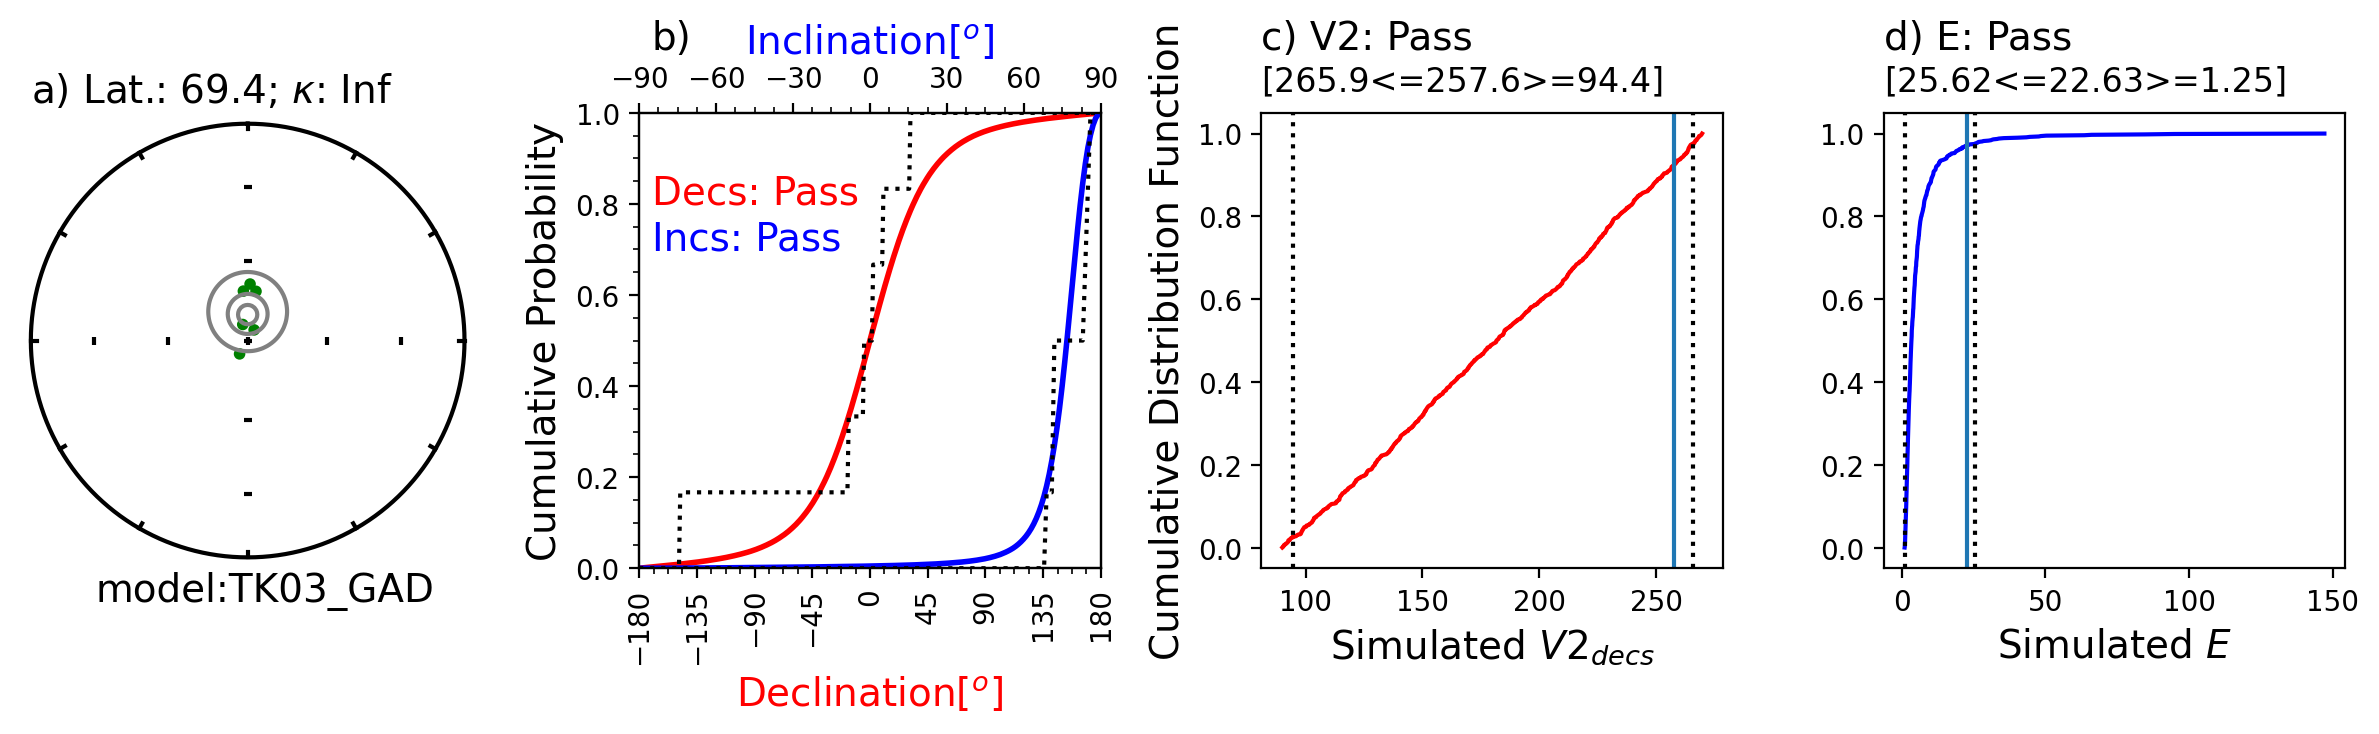

paleolatitude = 69.4 deg; elongation E = 22.63 (consistent with TK03.GAD)


In [11]:
_slat, _slon = float(A_tc['lat'].mean()), float(A_tc['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(A_tc, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(A_tc, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Catoctin pole in the context of the Laurentia APWP

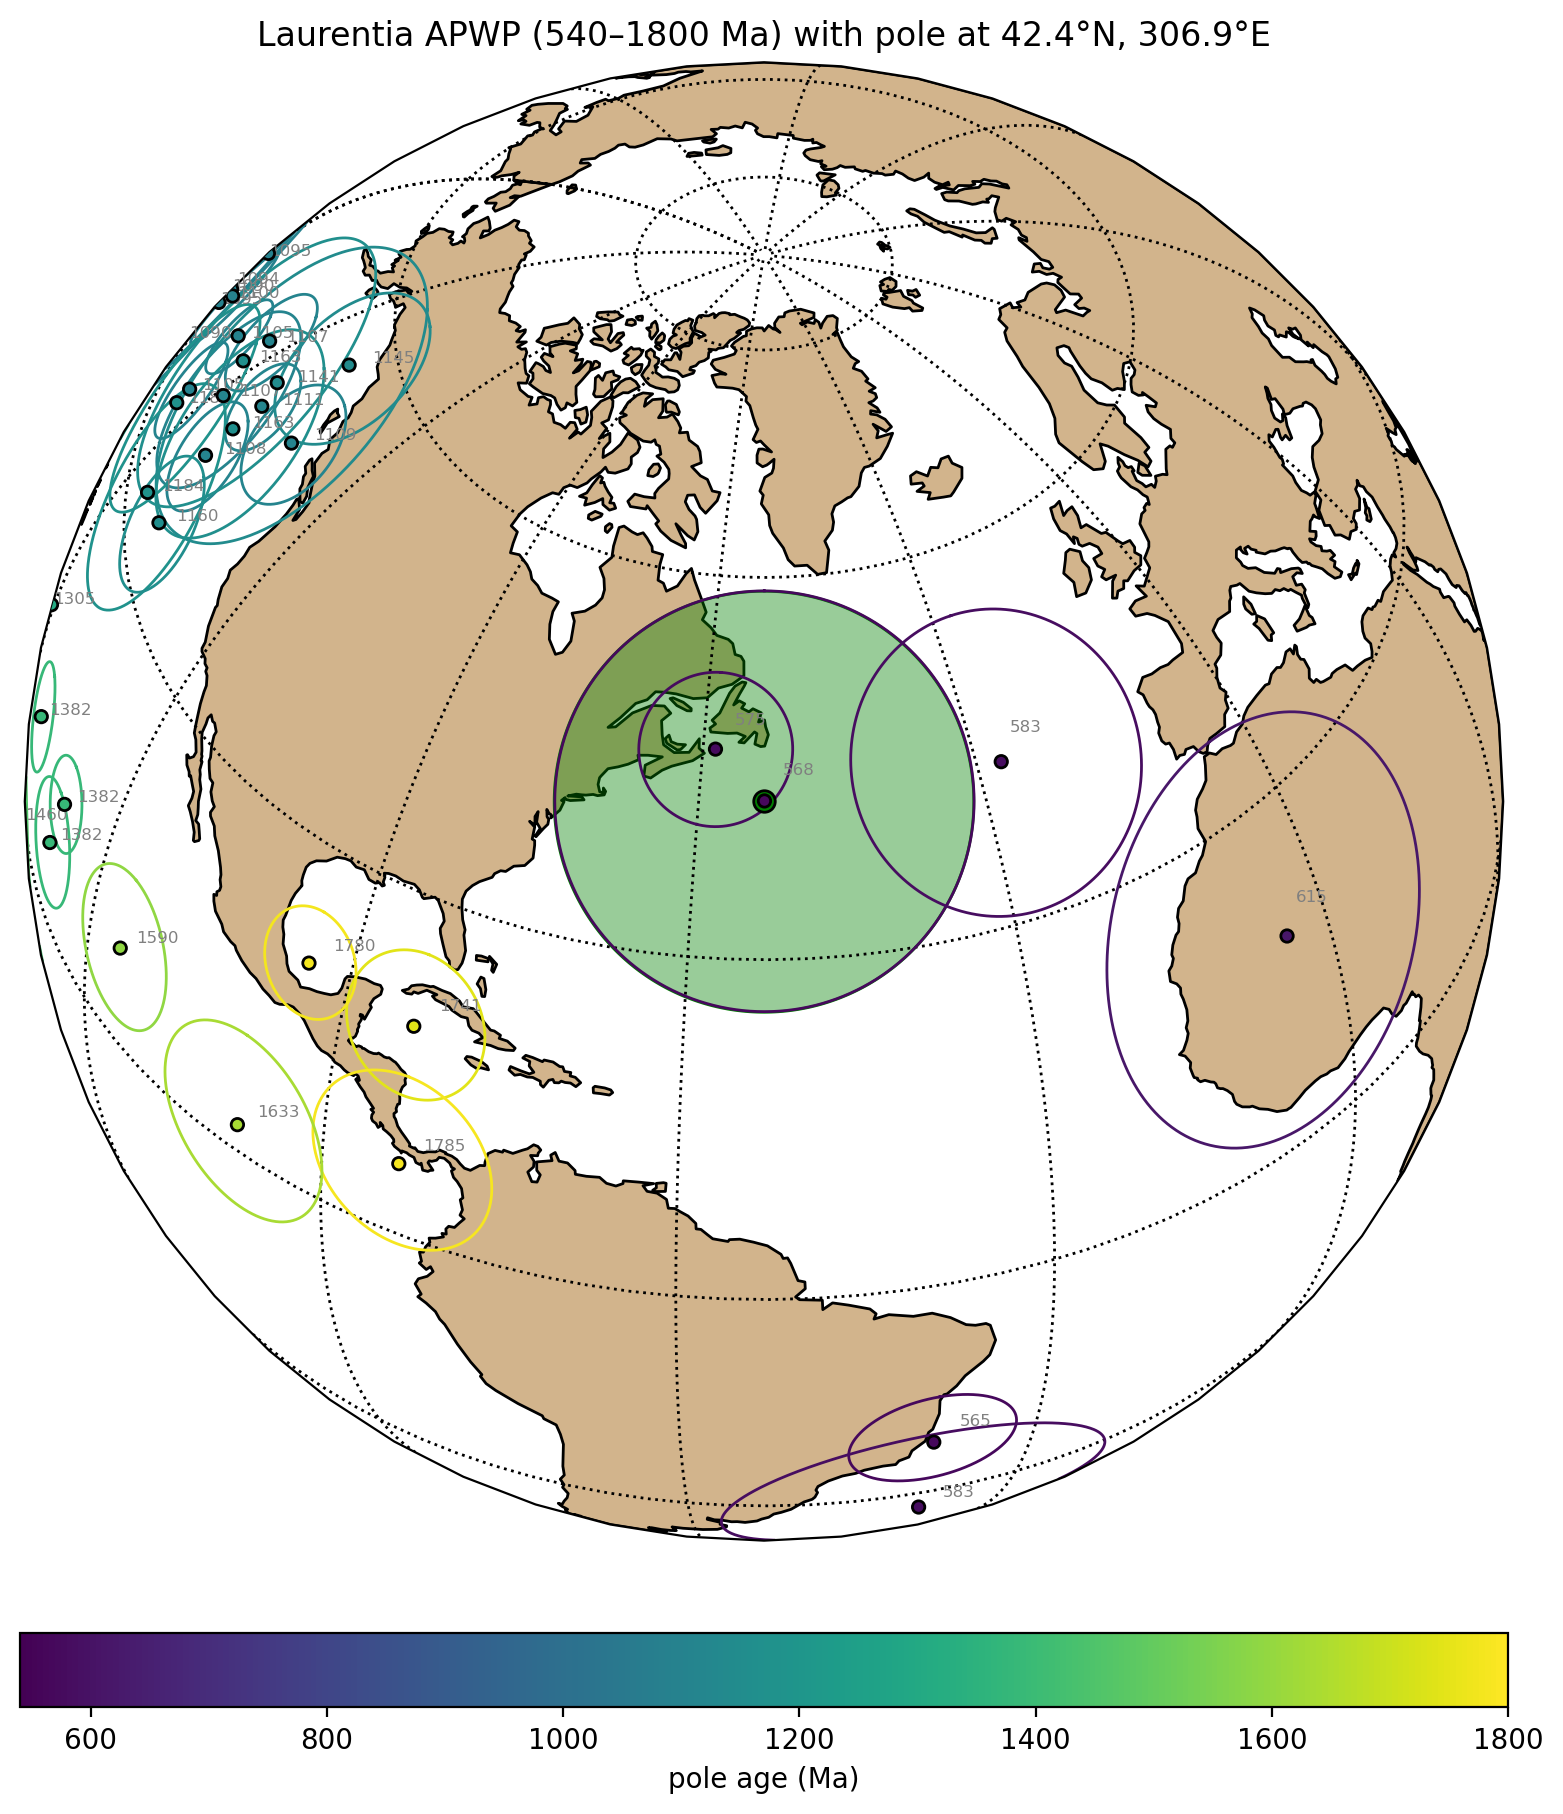

In [12]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=540, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

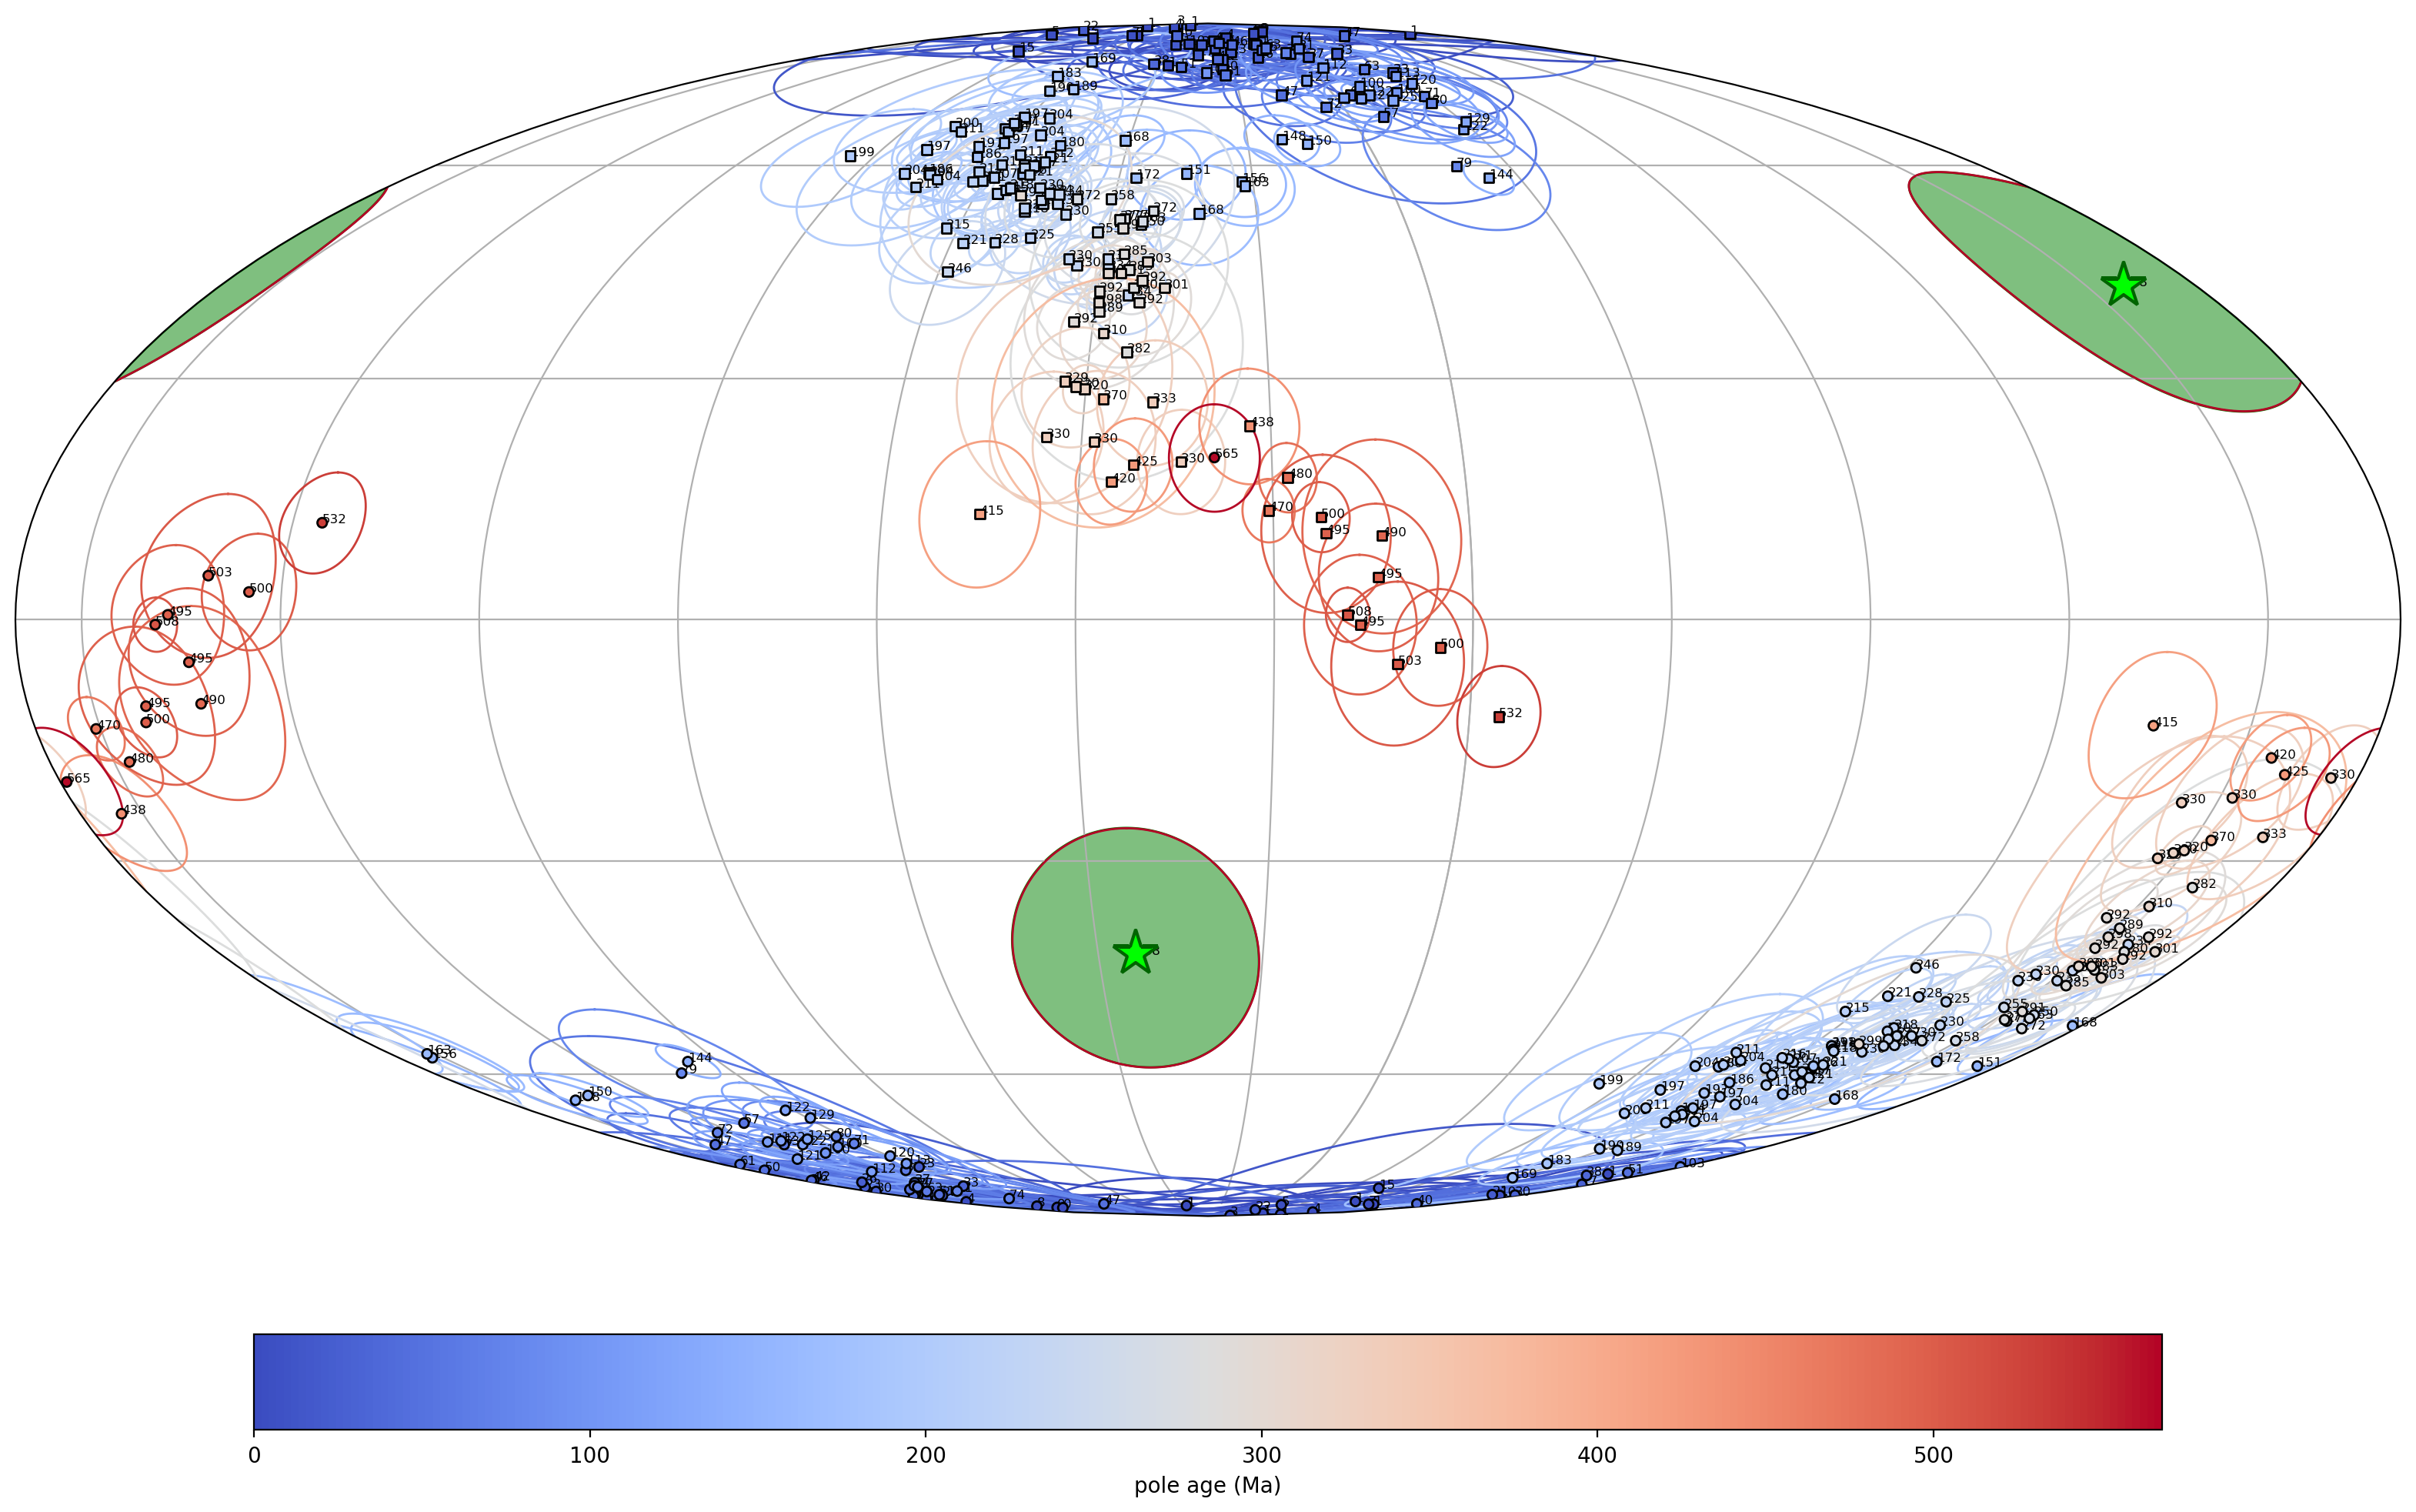

In [13]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Catoctin Basalts', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=568)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | ca. 568 Ma (555-577 Ma): U-Pb zircon Concordia intercept 572 ± 5 Ma on a feeder dike (Aleinikoff et al., 1995) and 207Pb/206Pb 564 ± 9 Ma on an interbedded rhyolite. |
| 2 | Techniques and statistical analysis | **0** | Thermal/AF demagnetization with PCA, but the A-component mean rests on only N = 6 site VGPs with a large A95 = 16.5° — paleosecular variation is marginally sampled. |
| 3 | Magnetic mineralogy characterized | **1** | The A component is carried by magnetite (unblocking 500-585 °C, IRM); the secondary B (hematite) / C (magnetite) components are characterized and separated. |
| 4 | Field tests constrain age of magnetization | **fC** | Positive fold test and positive baked-contact test (feeder dikes/sill bake the Pedlar Granite) on the A component. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Blue Ridge anticlinorium; site means tilt-corrected for the Taconic-Alleghanian folding. |
| 6 | Presence of reversals | **1** | The A component is of dual polarity and passes a reversal test. |
| 7 | No resemblance to younger poles | **1** | The A pole is distinct from the secondary Taconic (C) and Late Cambrian (B) remagnetization poles isolated in the same rocks. |
| | Total | **6/7** | Grade B |

## Nordic workshop summary

The Catoctin A-component pole is recreated from the site-level MagIC
contribution (Meert et al. 1994 Tables 1-2): 42.4°N/306.9°E, A95 16.5°
(= 43°S/128°E, N=6), reproducing the prior compilation (GPMDB 7474). A primary
origin of the component is supported by positive fold, reversal, and baked-contact tests; the
secondary B (Late Cambrian, 4°S/193°E) and C (Taconic, 19°N/143°E) remagnetizations
are documented in the contribution. R = 6, Grade B (R2 = 0: small N = 6, large
A95).

In [14]:
catoctin_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Catoctin Basalts',
    sites=A_tc,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='A component (steep, magnetite-carried) characteristic remanent magnetization; dual polarity',
    tests='C+ (positive baked-contact test, feeder dikes/sill bake the Pedlar Granite), F+ (positive fold test), Rc (positive reversal test, class C), M (dual-polarity record)',
    gpmdb_number='7474',
    percent_reversed=50,
    demag_code=4,
    R1=1, R2=0, R3=1, R4='fC', R5=1, R6=1, R7=1, Grade='B', Grade_E21='B',
    nominal_age=568, lomagage=555, himagage=577,
    REF_method="The age constraints for the Catoctin volcanic province come from a 572 ± 5 Ma Concordia isochron upper intercept U-Pb zircon date on a felsic dike within Grenville basement that is interpreted to be a feeder associated with the flows and a \n<sup>207</sup>Pb/<sup>206</sup>Pb zircon date of 564 ± 9 Ma from a rhyolitic flow in the Catoctin. Assign the mean age of these two with the uncertainty bounds including the uncertainty of each. We assign a nominal_age of 568 Ma with bounds that encompass the errors (lomagage=555 Ma, himagage=577).\n\nPrevious Nordic compilation noted that: *572±5 in felsic pod from lower Catoctin; 564 Ma in upper Catoctin -lower more applicable to basalts, Aleinikoff +95 Am.J.Sci*",
    POLE_AUTHORS='Meert, J. G., Van der Voo, R., & Payne, T. W.',
    YEAR=1994,
    JOURNAL='Journal of Geophysical Research',
    VOLUME='99',
    VPAGES='4625-4641',
    TITLE='Paleomagnetism of the Catoctin volcanic province: a new Vendian-Cambrian apparent polar wander path for North America',
    COMMENT='Pole calculated from site VGPs in Swanson-Hysell et al., 2026'
)
pt.save_nordic_summary(catoctin_summary, '572_Catoctin_Basalts')
catoctin_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Catoctin Basalts,GPMDB:7474,"A component (steep, magnetite-carried) charact...","C+ (positive baked-contact test, feeder dikes/...",100,38.5,281.8,6,28,...,577,U-Pb zircon Concordia intercept 572 +/- 5 Ma o...,Catoctin Basalts,"Meert, J. G., Van der Voo, R., & Payne, T. W.",1994,Journal of Geophysical Research,99,4625-4641,Paleomagnetism of the Catoctin volcanic provin...,Pole calculated from site VGPs in Swanson-Hyse...


## Comparison with the published pole of Meert et al. (1994)

The mean pole reported in this notebook is the **Fisher mean of the individual site VGPs** (`pt.compute_mean_pole`), with a single circular A95. Because the A-component inclination is very steep (I ≈ 84°), the pole-space uncertainty is much larger than the directional α95 (9°): it expands to a circular A95 ≈ 16.5°. The recreated pole therefore reports A95 = 16.5° with DP/DM left blank, whereas the prior compilation stored the same value as DP = DM = 16.5°. Meert et al. (1994) report the A pole in the opposite polarity, at 43°S, 128°E; this is the antipode of the 42.4°N, 306.9°E position used here and in the compilation, and is the same pole.

| Quantity | This study (site VGPs) | Meert et al. (1994), Table 2 | Previous Nordic compilation |
|---|---|---|---|
| Component | A | A | A |
| N (sites) | 6 | 6 | 6 |
| N (specimens) | 28 | 28 (of 37) | 28 |
| Dec (°, tilt-corr.) | 66.8 | 68 | 68 |
| Inc (°, tilt-corr.) | 83.6 | +84 | 84 |
| k | 60.3 | 59 | 59 |
| α95 (direction, °) | 8.7 | 9 | 9 |
| Pole lat (°N) | 42.4 | −43 | 42.4 |
| Pole lon (°E) | 306.9 | 128 | 306.9 |
| A95, pole (°) | 16.5 | — (circular, ≈16.5) | 16.5 |
| DP / DM (°) | — / — | — | 16.5 / 16.5 |
